# Sparse MNIST demo

The end-to-end SparsePixels workflow on MNIST: turn the dense images into a sparse (few-active-pixel) form, study them, build and train a sparse CNN with the monitor, and convert the trained model to HLS firmware.

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from keras.layers import Flatten, Activation, AveragePooling2D
from hgq.layers import QConv2D, QDense
from hgq.config import QuantizerConfigScope, LayerConfigScope
from sparsepixels.layers import *
from utils import *

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

n_val = 10000
X_val = X_train[:n_val]
y_val = y_train[:n_val]
X_train = X_train[n_val:]
y_train = y_train[n_val:]

X_train = np.reshape(X_train, (-1,28,28,1)) / 255.
X_val = np.reshape(X_val, (-1,28,28,1)) / 255.
X_test = np.reshape(X_test, (-1,28,28,1)) / 255.

y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("X_train.shape: " + str(X_train.shape))
print("y_train.shape: " + str(y_train.shape))
print("X_val.shape: " + str(X_val.shape))
print("y_val.shape: " + str(y_val.shape))
print("X_test.shape: " + str(X_test.shape))
print("y_test.shape: " + str(y_test.shape))

X_train.shape: (50000, 28, 28, 1)
y_train.shape: (50000, 10)
X_val.shape: (10000, 28, 28, 1)
y_val.shape: (10000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)


## Make it sparse

MNIST is dense, so we first make it detector-like: pool and pad each digit onto a 48x48 canvas and inflate it, optionally adding background noise. `pool_pad_noise_inflate` (from `utils.py`) does this; real detector data would already be sparse.

In [2]:
import os
import random
os.environ['PYTHONHASHSEED'] = str(1221)
random.seed(1221)
np.random.seed(1211)

noise_type='uniform'
#noise_type='poisson'
#noise_level=0.42
noise_level=0
inflate_factor=3.5
threshold=0.4
target_size_x=48
target_size_y=target_size_x

x_train = pool_pad_noise_inflate(X_train, pool_size=3, pool_type='avg', target_size=(target_size_x,target_size_y), noise_type=noise_type, noise_level=noise_level, inflate_factor=inflate_factor)
x_val = pool_pad_noise_inflate(X_val, pool_size=3, pool_type='avg', target_size=(target_size_x,target_size_y), noise_type=noise_type, noise_level=noise_level, inflate_factor=inflate_factor)
x_test = pool_pad_noise_inflate(X_test, pool_size=3, pool_type='avg', target_size=(target_size_x,target_size_y), noise_type=noise_type, noise_level=noise_level, inflate_factor=inflate_factor)

## Study the data

Pick a threshold and an initial budget `n`: `active_pixels_vs_threshold` shows how many pixels stay active as the threshold rises, and `plot_reduced_examples` shows what a candidate `(n, threshold)` keeps on a few images.

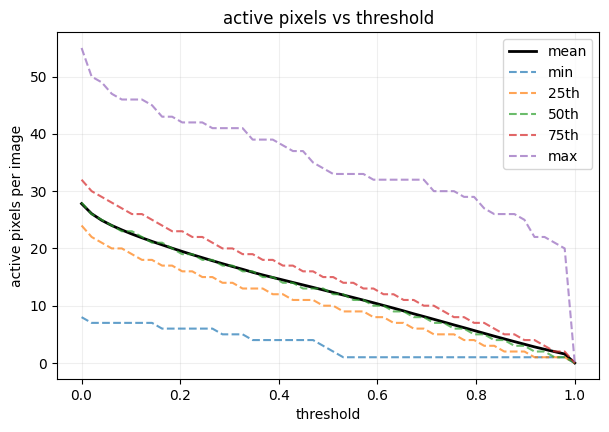

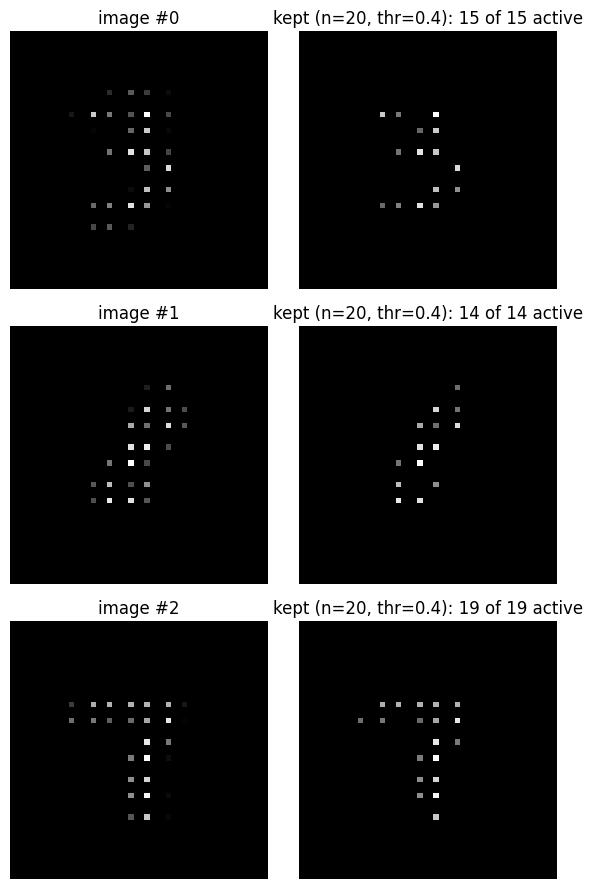

In [3]:
import os
FIG_DIR = '../docs/figs/demo'  # figures are reused on the docs 'Training & Monitoring' page
os.makedirs(FIG_DIR, exist_ok=True)

from sparsepixels.utils import active_pixels_vs_threshold, plot_reduced_examples

active_pixels_vs_threshold(x_train, save_path=f'{FIG_DIR}/active_pixels.png')
plot_reduced_examples(x_train, n=20, threshold=threshold, n_examples=3, save_path=f'{FIG_DIR}/reduced_examples.png')

## Build the sparse CNN

`InputReduce` keeps the first `n` active pixels above `threshold`, and the sparse conv / pooling layers run on that active-pixel set. `n` and `threshold` are trainable: `beta_n` drives `n` smaller and `beta_maskedE` keeps the threshold from over-masking. Starting from `threshold=0.0` with `learn_threshold=True` lets it learn the cut from scratch.

In [4]:
def build_model(n, threshold, beta_n, beta_maskedE, beta0, learn_n, learn_threshold):
    iq_conf = QuantizerConfig(place='datalane', q_type='kif', i0=4, f0=8, overflow_mode='WRAP')
    with (
        QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
        QuantizerConfigScope(place='datalane', default_q_type='kif', overflow_mode='WRAP'),
        LayerConfigScope(enable_ebops=True, enable_iq=True, beta0=beta0),
    ):
        x_in = keras.Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]), name='x_in')
        x, keep_mask = InputReduce(n=n, threshold=threshold, beta_n=beta_n, beta_maskedE=beta_maskedE,
                                    learn_n=learn_n, learn_threshold=learn_threshold,
                                    name='input_reduce')(x_in)

        x = QConv2DSparse(filters=2, kernel_size=7, name='conv1', padding='same', strides=1,
                            activation='relu', iq_conf=iq_conf)([x, keep_mask])
        x, keep_mask = AveragePooling2DSparse(4, name='pool1')([x, keep_mask])

        x = QConv2DSparse(filters=3, kernel_size=5, name='conv2', padding='same', strides=1,
                            activation='relu', iq_conf=iq_conf)([x, keep_mask])
        x, keep_mask = AveragePooling2DSparse(2, name='pool2')([x, keep_mask])

        x = Flatten(name='flatten')(x)
        x = QDense(36, name='dense1', activation='relu', iq_conf=iq_conf)(x)
        x = QDense(10, name='dense2', iq_conf=iq_conf)(x)
        x = Activation('softmax', name='softmax')(x)

    model = keras.Model(x_in, x, name='cnn_sparse')
    return model

model = build_model(n=35, threshold=0.0, beta_n=5e-3, beta_maskedE=1.0, beta0=1e-5, learn_n=True, learn_threshold=True)
print(model.summary())

Model: "cnn_sparse"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x_in (InputLayer)   │ (None, 48, 48, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_reduce        │ [(None, 48, 48,   │          3 │ x_in[0][0]        │
│ (InputReduce)       │ 1), (None, 48,    │            │                   │
│                     │ 48, 1)]           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1               │ (None, 48, 48, 2) │      7,315 │ input_reduce[0][… │
│ (QConv2DSparse)     │                   │            │ input_reduce[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ [(None, 12, 12,   │          0 │ conv1[0][0],      │
│ (AveragePooling2DS… │ 2), (None, 12,    │            │ input_reduce[0][… │
│                     │ 12, 1)]           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2               │ (None, 12, 12, 3) │      1,479 │ pool1[0][0],      │
│ (QConv2DSparse)     │                   │            │ pool1[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ [(None, 6, 6, 3), │          0 │ conv2[0][0],      │
│ (AveragePooling2DS… │ (None, 6, 6, 1)]  │            │ pool1[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 108)       │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (QDense)     │ (None, 36)        │     16,023 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (QDense)     │ (None, 10)        │      1,591 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax             │ (None, 10)        │          0 │ dense2[0][0]      │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,411 (81.83 KB)

 Trainable params: 16,379 (63.98 KB)

 Non-trainable params: 10,032 (17.85 KB)

None


## Train

Add `SparseTrainingMonitor` to the callbacks: it records the loss breakdown (task / EBOPS / budget / masked-intensity) and the learned budget/threshold each epoch, and sparse-corrects the EBOPS automatically. `plot_history` shows it all in one figure.

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.4738 - loss: 6.5294 - val_accuracy: 0.7091 - val_loss: 1.1537 - n_max_pixels: 29.0000 - threshold: 0.1529 - ebops: 383195.0000 - loss_ebops: 3.8319 - loss_n: 0.1450 - loss_maskedE: 0.0496 - loss_task: 2.5029
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7074 - loss: 3.7773 - val_accuracy: 0.7199 - val_loss: 1.1391 - n_max_pixels: 23.0000 - threshold: 0.3353 - ebops: 164939.0000 - loss_ebops: 1.6494 - loss_n: 0.1150 - loss_maskedE: 0.1494 - loss_task: 1.8635
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7268 - loss: 2.4064 - val_accuracy: 0.7529 - val_loss: 1.0822 - n_max_pixels: 20.0000 - threshold: 0.3900 - ebops: 98267.0000 - loss_ebops: 0.9827 - loss_n: 0.1000 - loss_maskedE: 0.1921 - loss_task: 1.1317
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7609 - loss: 2.0395 - val_accuracy: 0.7886 - val_loss: 0.9641 - n_max_pixels: 20.0000 - threshold: 0.3933 - 

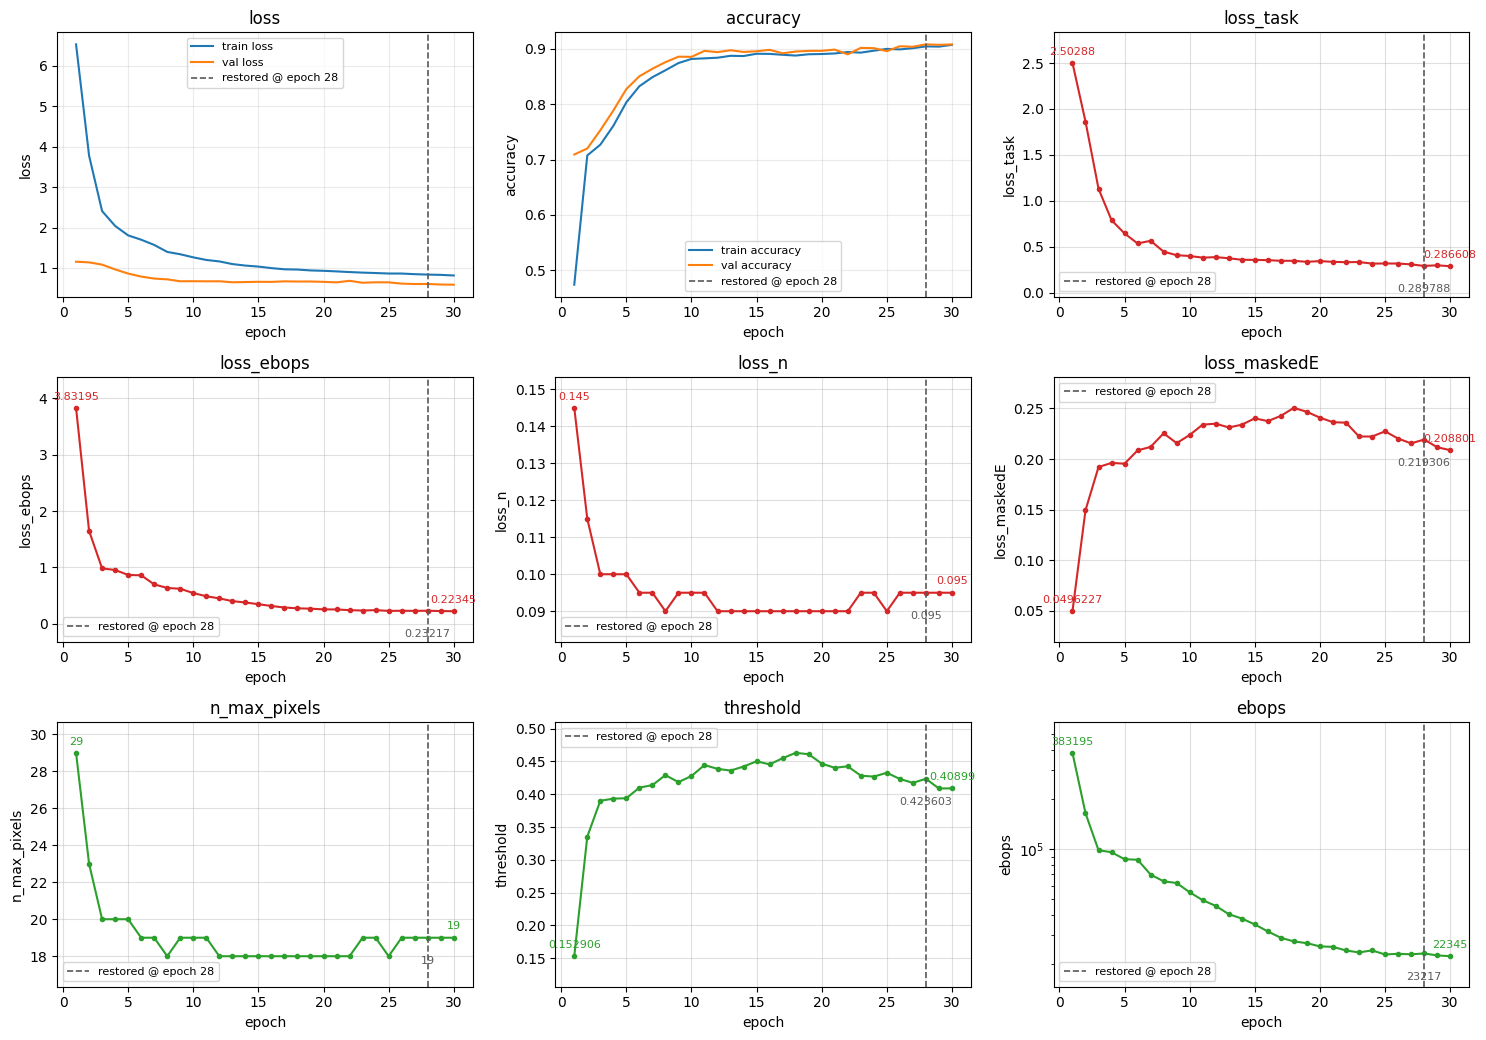

In [5]:
from sparsepixels.utils import SparseTrainingMonitor, plot_history

model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=128,
                         callbacks=[early_stop, SparseTrainingMonitor()])

ir = model.get_layer('input_reduce')
print(f"\nFinal: n_max_pixels = {ir.n_max_pixels}, threshold = {ir.threshold:.3f}")
plot_history(history, early_stopping=early_stop, save_path=f'{FIG_DIR}/history.png')

## Diagnostics

Test accuracy, plus the learned per-layer bit-widths and EBOPS from `print_quantization` / `plot_quantization`.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
acc = 0.9061

Model: cnn_sparse
Layer         #Kernel  #Bias  K mean   min   max  B mean   min   max  I mean   min   max       eBOPs
----------------------------------------------------------------------------------------------------
conv1              98      2     0.5   0.0   4.0     4.0   4.0   4.0     0.1   0.0   5.0         148
conv2             150      3     0.9   0.0   3.0     4.7   4.0   5.0     0.8   0.0   4.0        3492
dense1           3888     36     2.7   0.0   4.0     3.9   0.0   4.0     1.5   0.0   5.0       14354
dense2            360     10     3.3   0.0   4.0     4.0   4.0   4.0     4.3   0.0   5.0        5223
----------------------------------------------------------------------------------------------------
                                                                               Total eBOPs     23217


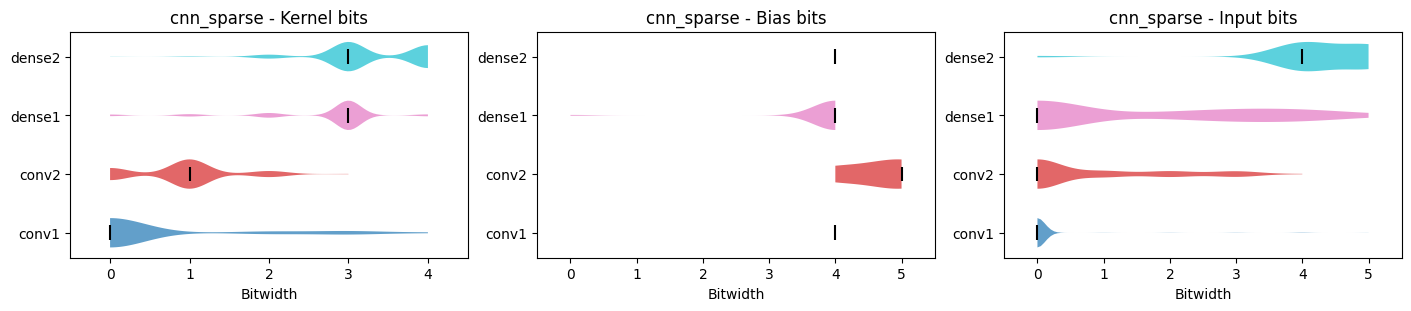

In [6]:
from sparsepixels.utils import print_quantization, plot_quantization

y_pred = model.predict(x_test)
print("acc = {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))))
print_quantization(model)
plot_quantization(model, save_path=f'{FIG_DIR}/quantization.png')

## Save and reload

Save the weights. Reloading requires rebuilding with the **same** `InputReduce` flags (`learn_n` / `learn_threshold` decide which weights the layer has).

In [7]:
model.save_weights('weights/mnist_sparse.weights.h5')

In [8]:
model = build_model(n=35, threshold=0.0, beta_n=5e-3, beta_maskedE=1.0, beta0=1e-5, learn_n=True, learn_threshold=True)
# ^ need to keep the same flags as the saved model
model.load_weights('weights/mnist_sparse.weights.h5')

## Convert to HLS

Convert the trained model to FPGA firmware with hls4ml (install the PR branch as shown on the Installation page). The converter reads the deployed budget/threshold off the model; the per-layer knobs below are optional and change only latency vs. resources.

In [9]:
import hls4ml

hls_config = hls4ml.utils.config_from_keras_model(model, granularity='name')
hls_config.setdefault('Model', {})['PipelineStyle'] = 'dataflow'

n_max_pixels = model.get_layer('input_reduce').n_max_pixels

# input reduce: 'tree' (default, lowest latency) or 'stream' (sequential, fewer resources)
hls_config['LayerName']['input_reduce']['Variant'] = 'tree'
# conv: active pixels in parallel (<= n_max_pixels), and filters in parallel (<= that conv's filters)
hls_config['LayerName']['conv1']['PixelParallelFactor'] = n_max_pixels
hls_config['LayerName']['conv1']['FiltParallelFactor'] = 2
hls_config['LayerName']['conv2']['PixelParallelFactor'] = n_max_pixels
hls_config['LayerName']['conv2']['FiltParallelFactor'] = 3
# pool: active pixels in parallel, and channels in parallel
hls_config['LayerName']['pool1']['PixelParallelFactor'] = n_max_pixels
hls_config['LayerName']['pool1']['ChanParallelFactor'] = 2
hls_config['LayerName']['pool2']['PixelParallelFactor'] = n_max_pixels
hls_config['LayerName']['pool2']['ChanParallelFactor'] = 3
# flatten: scatter positions in parallel (<= out_height * out_width; here 48*48 pools to 6*6)
hls_config['LayerName']['flatten']['ParallelFactor'] = 6 * 6

model_hls = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=hls_config,
    output_dir='hls_proj_test/cnn_sparse',
    backend='Vitis',
    part='xcu250-figd2104-2L-e',
    io_type='io_parallel',
)
model_hls.write()
model_hls.compile()

/Users/hofungtsoi/Desktop/hls4ml/hls4ml/model/optimizer/passes/bit_exact.py:984: UserWarning: Softmax layer softmax is converted from a frontend not supporting bit-exact softmax.
  warn(f'Softmax layer {node.name} is converted from a frontend not supporting bit-exact softmax.')


## Check against Keras

Compare the C-simulation of the generated firmware to the Keras model -- they agree up to the irreducible fixed-point rounding.

In [10]:
# compare model accuracy between keras and hls
n_compare = 5000
y_pred_keras = model.predict(x_test[:n_compare], verbose=0)
y_pred_hls = model_hls.predict(x_test[:n_compare]).reshape(y_pred_keras.shape)

keras_classes = np.argmax(y_pred_keras, axis=1)
hls_classes = np.argmax(y_pred_hls, axis=1)
true_classes = np.argmax(y_test[:n_compare], axis=1)
class_match = np.mean(keras_classes == hls_classes)

print(f"Keras vs HLS class agreement: {class_match:.1%} ({int(class_match*len(x_test[:n_compare]))}/{len(x_test[:n_compare])})")
print(f"Keras accuracy: {accuracy_score(true_classes, keras_classes):.4f}")
print(f"HLS accuracy:   {accuracy_score(true_classes, hls_classes):.4f}")

Keras vs HLS class agreement: 94.4% (4722/5000)
Keras accuracy: 0.8866
HLS accuracy:   0.8872


## Write test-bench data

Dump a spread of test samples (by active-pixel count) as `.dat` files for the HLS C-simulation test bench.

In [11]:
# write testbench data to hls
def count_active_pixels(x, threshold):
    """Count pixels above threshold in first channel for each sample."""
    return (x[..., 0] > threshold).reshape(x.shape[0], -1).sum(axis=1)

def select_diverse_samples(x, threshold, n_tb=50, min_active=5, max_active=40):
    """Select samples with a spread of active pixel counts."""
    counts = count_active_pixels(x, threshold)
    # Bin into target range
    mask = (counts >= min_active) & (counts <= max_active)
    valid_idx = np.where(mask)[0]
    valid_counts = counts[valid_idx]

    # Sort by count and pick evenly spaced
    order = np.argsort(valid_counts)
    valid_idx = valid_idx[order]
    valid_counts = valid_counts[order]

    if len(valid_idx) <= n_tb:
        selected = valid_idx
    else:
        step = len(valid_idx) / n_tb
        selected = valid_idx[np.round(np.arange(n_tb) * step).astype(int)]

    sel_counts = counts[selected]
    print(f"  Selected {len(selected)} samples, active pixels: "
          f"min={sel_counts.min()}, max={sel_counts.max()}, "
          f"mean={sel_counts.mean():.1f}, median={np.median(sel_counts):.0f}")
    print(f"  Distribution: {np.histogram(sel_counts, bins=[5,10,15,20,25,30,35,41])[0]}")
    return selected

def write_tb_data(keras_model, x, out_dir, indices):
    n_tb = len(indices)
    x_tb = x[indices]
    y_keras = keras_model.predict(x_tb, verbose=0)

    os.makedirs(out_dir, exist_ok=True)
    with open(f"{out_dir}/tb_input_features.dat", "w") as f:
        for row in x_tb.reshape(n_tb, -1):
            f.write(" ".join(f"{v:.8f}" for v in row) + "\n")
    with open(f"{out_dir}/tb_output_predictions.dat", "w") as f:
        for row in y_keras:
            f.write(" ".join(f"{v:.8f}" for v in row) + "\n")

    print(f"Test bench data written ({n_tb} samples) -> {out_dir}")


print("Selecting diverse samples by active pixel count...")
tb_indices = select_diverse_samples(x_test, threshold, n_tb=50, min_active=5, max_active=40)
write_tb_data(model, x_test, 'hls_proj_test/cnn_sparse/tb_data', tb_indices)

Selecting diverse samples by active pixel count...
  Selected 50 samples, active pixels: min=5, max=24, mean=14.5, median=14
  Distribution: [ 5 20 20  5  0  0  0]
Test bench data written (50 samples) -> hls_proj_test/cnn_sparse/tb_data
